In [2]:
print("UNIVERSIDAD ABIERTA Y A DISTANCIA - UNAD")
print("ANALISIS DE DATOS")
print("DATOS DE SEGMENTACION DE CLIENTES DE CENTROS COMERCIALES")
print("MODELO K-MEANS")
print("SARA LUCIA CORREDOR NARANJO")

UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD
ANALISIS DE DATOS
DATOS DE SEGMENTACION DE CLIENTES DE CENTROS COMERCIALES
MODELO K-MEANS
SARA LUCIA CORREDOR NARANJO


In [19]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#cargar el dataset
df = pd.read_csv('C:/UNAD/Mall_Customers.csv')

In [21]:
print("1. Análisis exploratorio de los datos EDA")

1. Análisis exploratorio de los datos EDA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Descripcion estadistica:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    

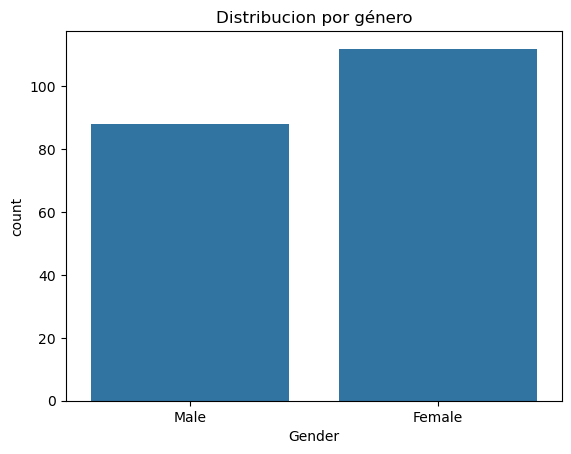

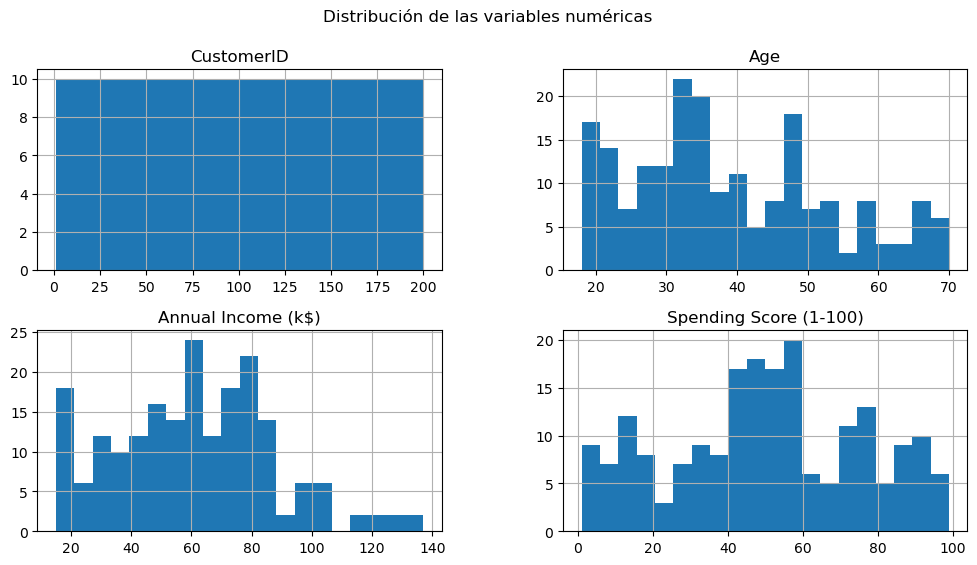

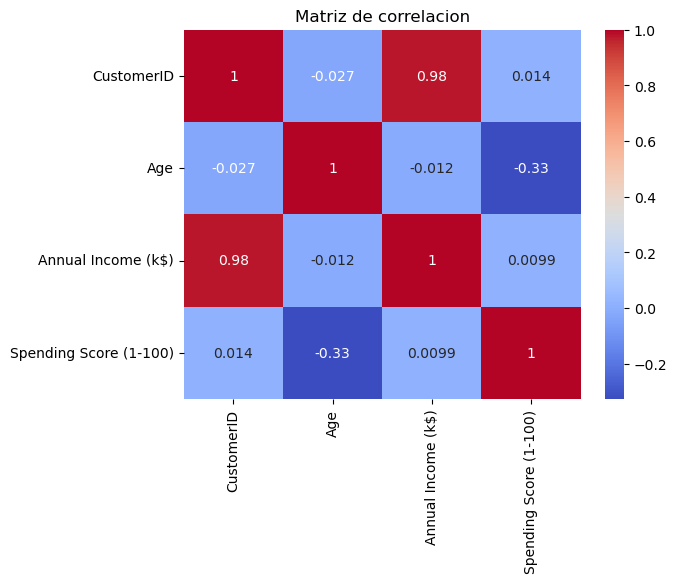

In [22]:
#Informacion general
print(df.info())
print("\nDescripcion estadistica:")
print(df.describe())

#Conteo por genero
sns.countplot(data=df, x='Gender')
plt.title('Distribucion por género')
plt.show()

#Histogramas
df.hist(bins=20, figsize=(12, 6))
plt.suptitle('Distribución de las variables numéricas')
plt.show()

#Matriz de correlacion
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de correlacion')
plt.show()


In [23]:
print("2. Procesamiento de los datos")

2. Procesamiento de los datos


In [24]:
#Comprobar valores faltantes
print(df.isnull().sum())

#Eliminar columna "CustomerID" ya que no aporta valor al modelo
df_cleaned = df.drop(columns=['CustomerID'])

#Codificacion del genero
df_cleaned['Gender'] = df_cleaned['Gender'].map({'Male': 0, 'Female': 1})

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [25]:
print("3. Seleccion de Caracteristicas")

3. Seleccion de Caracteristicas


In [26]:
from sklearn.preprocessing import StandardScaler

#Escalado de caracteristicas
features = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cleaned[features])

In [27]:
print("4. Entrenamiento del modelo K-Means")

4. Entrenamiento del modelo K-Means


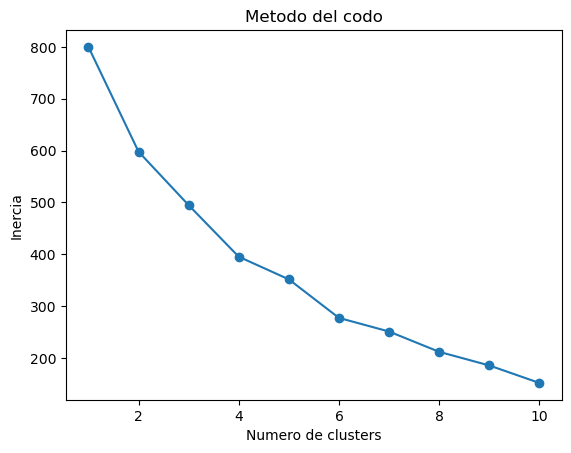

In [28]:
from sklearn.cluster import KMeans

#Metodo del codo para encontrar el numero optimo de clusters
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.title('Metodo del codo')
plt.xlabel('Numero de clusters')
plt.ylabel('Inercia')
plt.show()

#Entrenamiento final 
kmeans = KMeans(n_clusters=5, random_state=42)
df_cleaned['Cluster'] = kmeans.fit_predict(scaled_features)

In [30]:
print("5. Evaluacion del Modelo")

5. Evaluacion del Modelo


In [32]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

silhouette = silhouette_score(scaled_features, df_cleaned['Cluster'])
calinski = calinski_harabasz_score(scaled_features, df_cleaned['Cluster'])

print(f'Silhouette Score: {silhouette:.4f}')
print(f'Calinski-Harabasz Index: {calinski:.4f}')

Silhouette Score: 0.2719
Calinski-Harabasz Index: 62.1263


In [33]:
print("6. Visualizacion de resultados")

6. Visualizacion de resultados


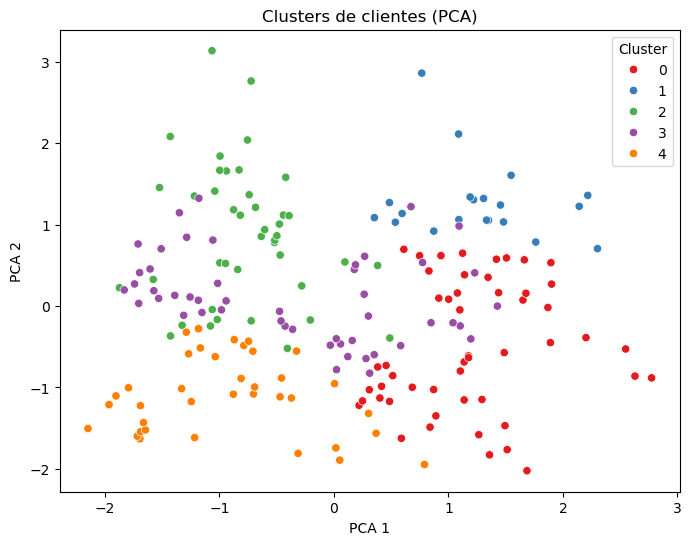

In [34]:
import numpy as np
from sklearn.decomposition import PCA

#Reduccion de dimensionalidad para visualizacion
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_components[:, 0], y=pca_components[:, 1],
                hue=df_cleaned['Cluster'], palette='Set1')
plt.title('Clusters de clientes (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

In [35]:
print("7. Interpretacion y Analisis")

7. Interpretacion y Analisis


In [36]:
cluster_summary = df_cleaned.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.490196  56.470588           46.098039               39.313725
1        0.000000  39.500000           85.150000               14.050000
2        0.000000  28.690476           60.904762               70.238095
3        1.000000  37.897959           82.122449               54.448980
4        1.000000  27.315789           38.842105               56.210526
